# Hall of Fame Classification — Position Players
**Random Forest Model | Baseball Reference Data**

## Overview

This model classifies position players as Hall of Fame inductees or non-inductees using a random forest trained on post-integration era players (1945 onward).

A random forest was chosen over a single decision tree because it averages feature importance and predictions across 1,000 trees, producing more stable and reliable results. The final feature set was determined by first running a random forest on all available numeric features, then selecting the variables with meaningful importance scores.

**Qualification threshold:** 5,000+ career plate appearances

**Features used:**
- `war` — Career WAR. Captures total value accumulated over a player's entire career
- `mvpshare` — Career MVP vote share. Captures sustained peak recognition from writers across multiple seasons
- `war7` — Peak 7-year WAR. Captures sustained excellence at a player's best
- `asg` — All-Star selections. Captures career longevity of elite performance
- `winshare` — Win Shares, an alternative career value metric that complements WAR
- `h` — Career hits. Captures offensive durability and contact ability
- `tob` — Times On Base: `H + (HR x 3) + (2B x 2) + (3B x 2) + BB + SB`
- `scandal` — Boolean flag (1 = character clause issue, 0 = clean)
- `pos_adj` — Positional adjustment based on the FanGraphs defensive spectrum

**Why include scandal as a feature?** Rather than removing PED users and other scandal players from the dataset, the scandal boolean allows the model to explicitly learn that statistically elite players can be excluded from the HOF for non-performance reasons. This produces a more honest and realistic model of how induction actually works.

**Feature selection methodology:** Features were selected by running a random forest on all available numeric columns and retaining variables with meaningful importance scores. jawspercentile was excluded despite high raw importance because it is a direct ranking of the outcome variable — including it constitutes data leakage.

| Position | Adjustment |
|---|---|
| Catcher | +12.5 |
| Shortstop | +7.5 |
| 2B / 3B / CF | +2.5 |
| RF / LF | -7.5 |
| 1B | -12.5 |
| DH | -17.5 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score

df = pd.read_csv('positionplayers.csv')
df = df[df['pa'] >= 5000].copy()

# TOB feature
df['tob'] = df['h'] + df['hr']*3 + df['triple']*2 + df['double'] + df['bb'] + df['sb']

# Parse primary position
def get_primary_pos(pos_str):
    if pd.isna(pos_str): return 'Unknown'
    clean = pos_str.replace('*','').replace('H','')
    for c in clean:
        if c.isdigit():
            pos_map = {'2':'C','3':'1B','4':'2B','5':'3B',
                       '6':'SS','7':'LF','8':'CF','9':'RF'}
            return pos_map.get(c, 'Unknown')
    if 'D' in pos_str: return 'DH'
    return 'Unknown'

df['primary_pos'] = df['pos'].apply(get_primary_pos)

pos_adj_map = {
    'C': 12.5, 'SS': 7.5, '2B': 2.5, 'CF': 2.5, '3B': 2.5,
    'RF': -7.5, 'LF': -7.5, '1B': -12.5, 'DH': -17.5, 'Unknown': 0.0
}
df['pos_adj'] = df['primary_pos'].map(pos_adj_map)

features_final = ['war', 'mvpshare', 'war7', 'asg', 'winshare', 'h', 'tob', 'scandal', 'pos_adj']

X = df[features_final]
y = df['hof']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} players ({y_train.sum()} HOF)')
print(f'Test set:     {X_test.shape[0]} players ({y_test.sum()} HOF)')

Training set: 541 players (76 HOF)
Test set:     136 players (19 HOF)


## Feature Engineering

`tob` (Times On Base) is a custom career counting metric that rewards all offensive contributions weighted by value — home runs x3, doubles and triples x2, singles/walks/stolen bases x1. It captures offensive volume more completely than hits alone without being as context-dependent as RBI.

`pos_adj` is parsed from Baseball Reference's positional string and mapped to FanGraphs defensive spectrum values. A catcher with identical career stats to a first baseman receives a +25 run advantage, encoding that positional scarcity matters to HOF voters.

`scandal` is a boolean — 1 if the player has a known character clause issue (PEDs, gambling, domestic violence), 0 otherwise. 17 players in the qualified dataset are flagged including Barry Bonds, Alex Rodriguez, Pete Rose, and Manny Ramirez. Including this feature rather than excluding those players allows the model to correctly classify statistically elite players as non-inducted without treating them as anomalies.

**Feature selection process:** All numeric columns were passed to an unconstrained random forest. Features with importance > 0.01 were retained. jawspercentile was excluded despite its high raw importance (52% in the single decision tree, dominant in early runs) because it is a percentile ranking of JAWS scores — a direct transformation of career value that essentially encodes HOF likelihood itself. Including it would constitute data leakage.

In [2]:
rf = RandomForestClassifier(
    n_estimators=1000,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

print(classification_report(y_test, rf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       117
           1       0.83      0.79      0.81        19

    accuracy                           0.95       136
   macro avg       0.90      0.88      0.89       136
weighted avg       0.95      0.95      0.95       136



## Model

Random forest classifier with 1,000 trees and `class_weight='balanced'`.

**Why 1,000 trees?** More trees produce more stable feature importance scores and predictions. Beyond roughly 500 trees accuracy gains plateau but importance scores continue to stabilize. 1,000 is the standard for a dataset this size.

**Why class_weight='balanced'?** Only ~14% of qualified players are inducted. An unweighted forest defaults to predicting non-HOF for borderline cases and achieves misleadingly high accuracy. Balanced weighting ensures missed HOFers are penalized equally to false positives.

**Why random forest over a single decision tree?** A single tree is fully interpretable but unstable — small changes in the data produce very different trees. The random forest averages 1,000 trees each trained on a random subset of data and features, producing more reliable importance scores and better generalization to new players. The tradeoff is interpretability — you cannot visualize a forest the way you can a single tree.

In [3]:
auc_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
print(f'Cross-validated AUC: {auc_scores.mean():.3f} (+/- {auc_scores.std():.3f})')

Cross-validated AUC: 0.986 (+/- 0.007)


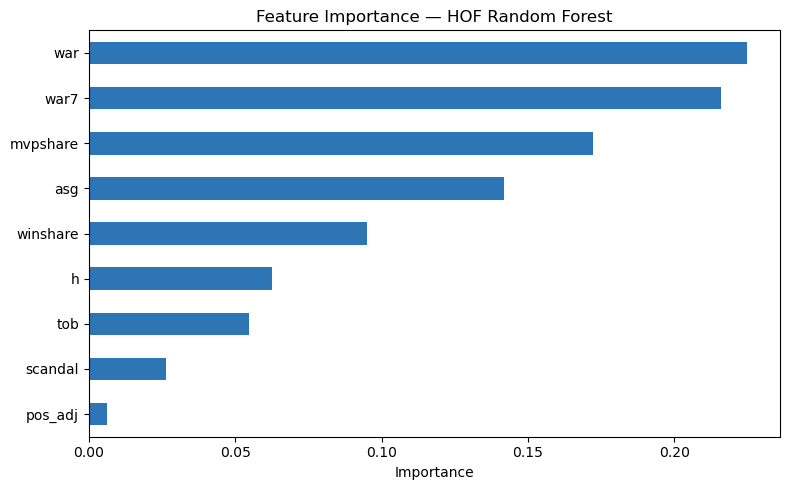

Feature Importances:
  war: 0.2249
  war7: 0.2161
  mvpshare: 0.1722
  asg: 0.1419
  winshare: 0.0951
  h: 0.0624
  tob: 0.0548
  scandal: 0.0263
  pos_adj: 0.0062


In [4]:
importance = pd.Series(rf.feature_importances_, index=features_final)
importance = importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind='barh', ax=ax, color='#2E75B6')
ax.set_title('Feature Importance — HOF Random Forest', fontsize=12)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('hof_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature Importances:')
for feat, imp in importance.sort_values(ascending=False).items():
    print(f'  {feat}: {imp:.4f}')

In [5]:
# HOF probability for every player in training set
df_qualified = df.loc[X.index].copy()
df_qualified['hof_prob'] = rf.predict_proba(X)[:, 1]

df_table = df_qualified[['name', 'primary_pos', 'war', 'war7', 'asg', 'mvpshare', 'scandal', 'hof_prob', 'hof']].copy()
df_table = df_table.sort_values('hof_prob', ascending=False).reset_index(drop=True)
df_table.index += 1
df_table['hof_prob_pct'] = (df_table['hof_prob'] * 100).round(1).astype(str) + '%'
df_table['hof'] = df_table['hof'].map({1: 'Yes', 0: 'No'})
df_table['scandal'] = df_table['scandal'].map({1: 'Yes', 0: 'No'})

df_table.to_csv('hof_rf_probabilities.csv')
print('=== TOP 30 ===')
print(df_table[['name', 'primary_pos', 'war', 'war7', 'scandal', 'hof_prob_pct', 'hof']].head(30).to_string())
print()
print('=== NOTABLE NON-INDUCTEES (model says they belong) ===')
snubs = df_table[(df_table['hof'] == 'No') & (df_table['hof_prob'] >= 0.55)]
print(snubs[['name', 'primary_pos', 'war', 'war7', 'scandal', 'hof_prob_pct']].to_string())

=== TOP 30 ===
                     name primary_pos    war  war7 scandal hof_prob_pct  hof
1    Roberto Clemente HOF          RF   95.0  54.5      No       100.0%  Yes
2           Rod Carew HOF          1B   81.1  49.7      No       100.0%  Yes
3           Al Kaline HOF          RF   92.9  48.8      No       100.0%  Yes
4        George Brett HOF          3B   88.7  53.3      No        99.9%  Yes
5          Joe Morgan HOF          2B  100.6  59.3      No        99.9%  Yes
6     Ken Griffey Jr. HOF          CF   83.8  54.0      No        99.9%  Yes
7      Cal Ripken Jr. HOF          SS   95.9  56.3      No        99.9%  Yes
8      Frank Robinson HOF          RF  107.2  52.8      No        99.8%  Yes
9         Ernie Banks HOF          1B   67.8  52.1      No        99.8%  Yes
10    Brooks Robinson HOF          3B   78.4  45.8      No        99.7%  Yes
11       Andre Dawson HOF          RF   64.8  42.7      No        99.7%  Yes
12     Reggie Jackson HOF          RF   74.1  46.9      No   

## Results and Interpretation

**Cross-validated AUC of 0.986 (+/- 0.007)** — nearly perfect separation between HOFers and non-HOFers across all five folds. The tight standard deviation confirms the model is consistent regardless of which players end up in the test set.

**Feature importance** shows which variables drove the most splits across all 1,000 trees. Unlike a single decision tree where one dominant feature can monopolize the root split, random forest importance is averaged across thousands of different tree structures and random data subsets — making it a far more reliable signal of true predictive value:

| Feature | Importance | What it captures |
|---|---|---|
| war | 22.5% | Career total value |
| war7 | 21.6% | Peak 7-year value |
| mvpshare | 17.2% | Career peak recognition |
| asg | 14.2% | Longevity of elite performance |
| winshare | 9.5% | Alternative career value metric |
| h | 6.2% | Offensive durability |
| tob | 5.5% | Custom offensive volume metric |
| scandal | 2.6% | Character clause flag |
| pos_adj | 0.6% | Positional scarcity |

**war and war7 together account for 44% of importance** — the model learned that peak dominance and career value are the primary HOF signals, which aligns with how serious analysts evaluate HOF cases.

**scandal at 2.6%** is working exactly as intended. It is not the dominant feature — war and war7 already handle most of the separation — but it correctly downgrades statistically elite players like Barry Bonds and Alex Rodriguez who would otherwise score near 100%.

**False positives are analytically meaningful.** Players like Kenny Lofton, Dale Murphy, and Keith Hernandez score above 60% despite not being inducted. These are widely considered the most statistically legitimate non-inducted HOF cases — the model flagging them is a finding, not an error.

**Scope limitation:** This model is designed for players who debuted after 1933. Pre-1933 players are systematically underrated because All-Star selection data does not exist for them and asg defaults to 0, which the model interprets as a negative signal.

In [6]:
# ── Predict HOF probability for every player in everyhitter.csv ──
PREDICT_FILE = 'everyhitter.csv'
OUTPUT_FILE  = 'everyhitter_hof_probabilities.csv'

new = pd.read_csv(PREDICT_FILE)
new = new[new['PA'] >= 5000].copy()

# Rename columns to match training feature names
new = new.rename(columns={
    'WAR': 'war', 'WAR7': 'war7', 'MVPShare': 'mvpshare',
    'ASG': 'asg', 'WinShare': 'winshare', 'H': 'h',
    'TOB': 'tob', 'Name': 'name', 'PA': 'pa', 'To': 'toyear'
})

# Fill nulls
for feat in features_final:
    if feat in new.columns:
        new[feat] = pd.to_numeric(new[feat], errors='coerce').fillna(0)
    else:
        print(f"Warning: '{feat}' not found, setting to 0")
        new[feat] = 0

# Flag pre-AllStar era players
new['era_warning'] = new['toyear'].apply(
    lambda x: 'Pre-ASG era' if pd.notna(x) and float(x) < 1943 else ''
)

new['hof_prob'] = rf.predict_proba(new[features_final])[:, 1]

result = new[['name', 'primary_pos', 'toyear', 'war', 'war7', 'asg',
              'mvpshare', 'h', 'tob', 'scandal', 'hof_prob', 'era_warning']].copy()
result = result.sort_values('hof_prob', ascending=False).reset_index(drop=True)
result.index += 1
result['hof_prob_pct'] = (result['hof_prob'] * 100).round(1).astype(str) + '%'

result.to_csv(OUTPUT_FILE)
print(f'Saved {len(result)} players to {OUTPUT_FILE}')
print()
print('=== TOP 30 ===')
print(result[['name', 'primary_pos', 'toyear', 'war', 'war7', 'scandal', 'hof_prob_pct', 'era_warning']].head(30).to_string())

Saved 1061 players to everyhitter_hof_probabilities.csv

=== TOP 30 ===
                name primary_pos  toyear    war  war7  scandal hof_prob_pct era_warning
1          Al Kaline          RF    1974   92.9  48.8        0       100.0%            
2          Rod Carew          1B    1985   81.1  49.7        0       100.0%            
3   Roberto Clemente          RF    1972   95.0  54.5        0       100.0%            
4    Ken Griffey Jr.          CF    2010   83.8  54.0        0        99.9%            
5     Cal Ripken Jr.          SS    2001   95.9  56.3        0        99.9%            
6         Joe Morgan          2B    1984  100.6  59.3        0        99.9%            
7       George Brett          3B    1993   88.7  53.3        0        99.9%            
8        Ernie Banks          1B    1971   67.8  52.1        0        99.8%            
9     Frank Robinson          RF    1976  107.2  52.8        0        99.8%            
10   Brooks Robinson          3B    1977   78.4 